<h1 style="text-align: center; color: darkblue;">Analysis</h1>

### 📑 <font color='blue'> Table of Contents </font>
1. [Introduction](#1)
2. [Setup](#2)
3. [Helper Functions](#3)
4. [Models](#4) <br>
    4.1. [Tree](#4.1) <br>
    4.2. [Neural Network](#4.2) <br>
5. [Comparison](#5)
6. [Conclusions](#6)

## <a id="1" style="color: darkred; text-decoration: none;">1. Introduction</a>


This notebook focuses on a detailed analysis of the best models obtained for each model type in the traffic classification task.
The goal is to better understand how each model makes its predictions and to compare their behavior and interpretability.

We start by analyzing the best-performing model of each family (e.g., tree-based models and neural networks) individually.
For tree-based models, we explore feature importance to identify which variables most influence the predictions.
For neural networks, we employ SHAP values to visualize and interpret feature contributions at a deeper level.

Finally, we perform a side-by-side comparison of the models, summarizing their performance and interpretability insights to highlight their respective strengths and limitations.


## <a id="2" style="color: darkred; text-decoration: none;">2. Setup </a>

In [31]:
import mlflow
import pandas as pd
from mlflow.tracking import MlflowClient
from pathlib import Path
import matplotlib.pyplot as plt
import json
import numpy as np
import time

import os, sys
import torch
import seaborn as sns

In [2]:
print(Path().resolve().parent)

/home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security


In [3]:
mlflow_path = Path().resolve().parent / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{mlflow_path}")

In [4]:
EXPERIMENT_NAME = "network_security"
N_RUNS = 100 # to meeasure inference time

## <a id="3" style="color: darkred; text-decoration: none;">3. Helper Functions </a>

In [5]:
def select_best_model(experiment_name, metric="f1", model_type='tree', data_version="v1"):
    client = MlflowClient()
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment is None:
        raise ValueError(f"Experiment '{experiment_name}' not found.")

    # Build filter
    filter_str = f"run_name = 'Tuning' AND tags.data_version = '{data_version}'"
    if model_type:
        filter_str += f" AND tags.model_type = '{model_type}'"

    # Search runs
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=filter_str,
        order_by=[f"metrics.{metric} DESC"],
    )

    if not runs:
        raise ValueError(f"No runs found for model_type='{model_type}' and data_version='{data_version}'.")

    # Take best run
    best_run = runs[0]
    run_id = best_run.info.run_id
    
    return best_run

## <a id="4" style="color: darkred; text-decoration: none;"> 4. Models </a>

### <a id="4.1" style="color: darkorange; text-decoration: none;"> 4.1. Tree </a>

In [6]:
best_tree_run = select_best_model(EXPERIMENT_NAME, model_type='tree')

2025/11/07 20:14:33 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/11/07 20:14:33 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


In [7]:
# Get metrics and params
metrics = best_tree_run.data.metrics
params = best_tree_run.data.params


# Converto to dataframe
df_params_tree = pd.DataFrame({
    "param": list(params.keys()),
    "value": list(params.values())
})


df_metrics_tree = pd.DataFrame({
    "metric": list(metrics.keys()),
    "value": list(metrics.values())
})

df_params_tree

,param,value
0,balance_factor,0.2
1,val_size,0.1
2,train_shape,"(169235, 78)"
3,val_shape,"(7731, 78)"
4,criterion,log_loss
5,max_depth,15
6,min_samples_split,5


In [8]:
df_metrics_tree

,metric,value
0,accuracy,0.997413
1,precision,0.997434
2,recall,0.997413
3,f1,0.997416


**Feature importance**

In [9]:
# best tree run id
best_tree_run_id = best_tree_run.info.run_id

# Load the model
tree_model = mlflow.sklearn.load_model(f"runs:/{best_tree_run_id}/model")

In [10]:
print(tree_model)

DecisionTreeClassifier(criterion='log_loss', max_depth=15, min_samples_split=5,
                       random_state=42)


**Inference Time**

In [11]:
def measure_inference_time_tree(model, n_features, n_samples=1, n_runs=100):
    times = []
    for _ in range(n_runs):
        X_sample = np.random.rand(n_samples, n_features)
        start = time.perf_counter()
        _ = model.predict(X_sample)
        end = time.perf_counter()
        times.append((end - start) / n_samples)  # per-sample latency
    return np.mean(times), np.std(times)

n_features = 78
mean_t, std_t = measure_inference_time_tree(tree_model, n_features)
print(f"Tree avg inference time: {mean_t*1000:.3f} ms ± {std_t*1000:.3f} ms")

Tree avg inference time: 0.253 ms ± 0.248 ms


In [25]:
# append inference time as new row
df_metrics_tree.loc[len(df_metrics_tree)] = ['inference_time (s)', mean_t]

In [26]:
df_metrics_tree

,metric,value
0,accuracy,0.997413
1,precision,0.997434
2,recall,0.997413
3,f1,0.997416
4,inference_time (s),0.000253


### <a id="4.2" style="color: darkorange; text-decoration: none;"> 4.2. Neural Network </a>

In [14]:
best_nn_run = select_best_model(EXPERIMENT_NAME, model_type='nn')

In [15]:
# Get metrics and params
metrics = best_nn_run.data.metrics
params = best_nn_run.data.params


# Converto to dataframe
df_params_nn = pd.DataFrame({
    "param": list(params.keys()),
    "value": list(params.values())
})


df_metrics_nn = pd.DataFrame({
    "metric": list(metrics.keys()),
    "value": list(metrics.values())
})

df_params_nn

,param,value
0,balance_factor,0.2
1,val_size,0.1
2,train_shape,"(169235, 78)"
3,val_shape,"(7731, 78)"
4,scaler_type,standard
5,lr,0.000895698148772964
6,final_lr,0.000895698148772964
7,hidden1,64
8,hidden2,32
9,batch_size,64


In [16]:
df_metrics_nn

,metric,value
0,accuracy,0.966499
1,precision,0.975215
2,recall,0.966499
3,f1,0.969358


In [62]:
# Load model
#import src
sys.path.append(os.path.abspath(".."))  # if notebook is inside /notebooks

import mlflow.pytorch


best_nn_run_id = best_nn_run.info.run_id


artifact_paths = {
    "preprocessing": "preprocessing",   #change!!!!!!!    # folder under artifacts
    "plots": "plots",                        # folder under artifacts
    "model": "model"                         # model artifact path
}

# --------------------------
model_uri = f"runs:/{best_nn_run_id}/{artifact_paths['model']}"
model = mlflow.pytorch.load_model(model_uri)
print("TensorFlow model loaded successfully!")


print(model)

TensorFlow model loaded successfully!
NNModel(
  (model): Sequential(
    (0): Linear(in_features=78, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=10, bias=True)
  )
)


**Inference time**

In [18]:
def measure_inference_time(model, sample_input, n_runs=100, device='cpu'):
    model.eval()
    model.to(device)
    sample_input = sample_input.to(device)

    # Warm-up (to stabilize GPU/CPU performance)
    for _ in range(10):
        _ = model(sample_input)

    torch.cuda.synchronize(device) if device.startswith('cuda') else None

    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.perf_counter()
            _ = model(sample_input)
            torch.cuda.synchronize(device) if device.startswith('cuda') else None
            end = time.perf_counter()
            times.append(end - start)

    mean_time = np.mean(times)
    std_time = np.std(times)
    return mean_time, std_time


In [19]:
sample_input = torch.randn(1, 78)  # adjust to your model’s input shape
mean_nn, std_nn = measure_inference_time(model, sample_input, n_runs=100, device='cpu')
print(f"Avg inference time: {mean_nn*1000:.3f} ms ± {std_nn*1000:.3f} ms")

Avg inference time: 0.113 ms ± 0.153 ms


In [22]:
# append inference time as new row
df_metrics_nn.loc[len(df_metrics_nn)] = ['inference_time (s)', mean_nn]

In [23]:
df_metrics_nn

,metric,value
0,accuracy,0.966499
1,precision,0.975215
2,recall,0.966499
3,f1,0.969358
4,inference_time (s),0.000113


## <a id="5" style="color: darkred; text-decoration: none;"> 5. Comparison </a>


In [29]:
# Give names to the model types
df1 = df_metrics_tree.rename(columns={'value': 'Tree'})
df2 = df_metrics_nn.rename(columns={'value': 'Neural Network'})

dfs = [df1, df2] 
comparison = dfs[0]
for df in dfs[1:]:
    comparison = comparison.merge(df, on='metric')

comparison

,metric,Tree,Neural Network
0,accuracy,0.997413,0.966499
1,precision,0.997434,0.975215
2,recall,0.997413,0.966499
3,f1,0.997416,0.969358
4,inference_time (s),0.000253,0.000113


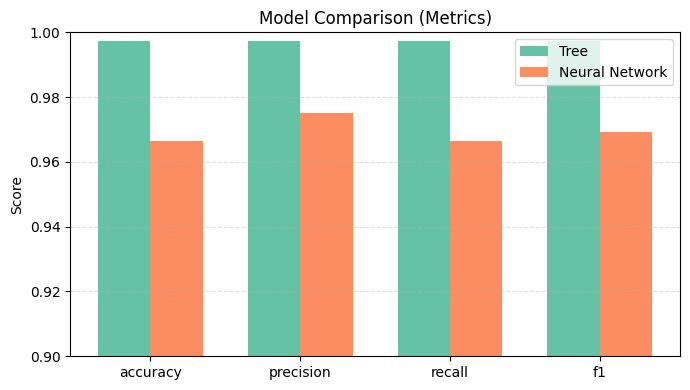

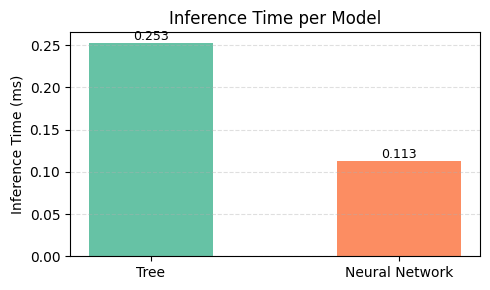

In [32]:
df = comparison

# Split metrics vs timing
df_metrics = df[df['metric'] != 'inference_time (s)']
df_time = df[df['metric'] == 'inference_time (s)']

# Use consistent color palette
models = df.columns[1:]
colors = sns.color_palette("Set2", n_colors=len(models))
color_map = dict(zip(models, colors))

# --- METRICS PLOT ---
df_melted = df_metrics.melt(id_vars='metric', var_name='Model', value_name='Score')

plt.figure(figsize=(7,4))
width = 0.35

for i, model in enumerate(models):
    subset = df_melted[df_melted['Model'] == model]
    plt.bar(
        [x + i*width for x in range(len(subset))],
        subset['Score'],
        width=width,
        label=model,
        color=color_map[model]
    )

plt.xticks([r + width/2 for r in range(len(df_metrics))], df_metrics['metric'])
plt.ylabel("Score")
plt.title("Model Comparison (Metrics)")
plt.ylim(0.9, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# --- INFERENCE TIME PLOT ---
df_time_melted = df_time.melt(id_vars='metric', var_name='Model', value_name='Time (s)')

plt.figure(figsize=(5,3))
bars = plt.bar(
    df_time_melted['Model'],
    df_time_melted['Time (s)'] * 1000,
    color=[color_map[m] for m in df_time_melted['Model']],
    width=0.5
)

# Add labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha='center', va='bottom', fontsize=9
    )

plt.ylabel("Inference Time (ms)")
plt.title("Inference Time per Model")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## <a id="6" style="color: darkred; text-decoration: none;"> 6. Conclusions </a>

In [ ]:
# for now i did not include preprocessing time!!!!!!!

In [33]:
from src.preprocessors.factory import PreprocessorFactory 





In [36]:
from src.preprocessors.nn_preprocessor import NNPreprocessor

In [38]:
import mlflow
import joblib
import os


artifact_paths = {
    "preprocessing": "preprocessor",       # folder under artifacts
    "plots": "plots",                        # folder under artifacts
    "model": "model"                         # model artifact path
}



# Define the artifact path where you saved the scaler
scaler_artifact_path = f"runs:/{best_nn_run_id}/{artifact_paths['preprocessing']}"

# Download artifacts to a local temp directory
local_dir = mlflow.artifacts.download_artifacts(scaler_artifact_path)

# List files to confirm what's inside
print("Downloaded files:", os.listdir(local_dir))

# Load the scaler (assuming it's named scaler.pkl or scaler.joblib)
scaler_path = os.path.join(local_dir, "scaler.pkl")  # or "scaler.joblib"
scaler = joblib.load(scaler_path)

print("Scaler loaded successfully!")


Downloaded files: ['label_encoder.pkl', 'scaler.pkl']
Scaler loaded successfully!


In [39]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [47]:
df = pd.read_csv("../data/test_data.csv", encoding="latin1")

df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,1145,91,2,2,4,12,2,2,2.0,0.0,...,24,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,53,232,2,2,64,152,32,32,32.0,0.0,...,40,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,53,176,2,2,72,328,36,36,36.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,53,69780,1,1,46,197,46,46,46.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,80,11932636,4,0,24,0,6,6,6.0,0.0,...,20,328.0,0.0,328,328,11900000.0,0.0,11900000,11900000,DDoS


In [50]:
from types import SimpleNamespace

# later real values!!!!!!!!!

# Simulate global configuration
global_cfg = SimpleNamespace(
    batch_size=64,
    random_state=42
)

# Simulate preprocessing configuration
pre_cfg = SimpleNamespace(
    path="data/processed/train.csv",
    #features=["src_ip", "dst_ip", "packet_size", "protocol"],
    features=None,
    balance_factor=0.2,
    val_size=0.2,
    scaler_type="standard"  # options: 'standard', 'minmax', 'robust', 'none'
)

# Example of instantiation

preprocessor = NNPreprocessor(global_cfg, pre_cfg)


In [51]:
preprocessor 

In [52]:
# nn needs scaler and encoder

data_prep = {
            "df": df,
            "scaler": scaler,
        }

X_values = preprocessor.preprocess_inference(**data_prep)

# then predict



In [53]:
X_values

array([[-0.24996326, -0.60288297, -0.00966246, ..., -0.22803409,
        -0.49938332, -0.4322915 ],
       [-0.33076829, -0.60287925, -0.00966246, ..., -0.22803409,
        -0.49938332, -0.4322915 ],
       [-0.33076829, -0.60288073, -0.00966246, ..., -0.22803409,
        -0.49938332, -0.4322915 ],
       ...,
       [-0.32877036, -0.45774139,  0.01209337, ..., -0.22803409,
        -0.49938332, -0.4322915 ],
       [-0.32877036, -0.34027455, -0.00531129, ..., -0.22803409,
        -0.19404246, -0.11203996],
       [-0.33076829, -0.60202914, -0.00966246, ..., -0.22803409,
        -0.49938332, -0.4322915 ]], shape=(19479, 78))

In [54]:
from src.inference.nn import NNPredictor



In [60]:
encoder_path = os.path.join(local_dir, "label_encoder.pkl")  # or "scaler.joblib"
encoder = joblib.load(encoder_path)

print("Encoder loaded successfully!")

encoder

Encoder loaded successfully!


LabelEncoder()

In [61]:
type(model)

str

In [63]:
predictor = NNPredictor(model, encoder, scaler)

In [64]:
preds = predictor.predict(X_values)

/home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security/env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [65]:
preds

array(['BENIGN', 'BENIGN', 'BENIGN', ..., 'BENIGN', 'BENIGN', 'BENIGN'],
      shape=(19479,), dtype=object)

In [ ]:
# MEDIR BIEN -> PREP + INFERENCE